In [2]:
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
from sklearn.metrics.pairwise import pairwise_distances

np.random.seed(123)

# Johnsons-Lindenstrauss embeddings

In this exercise, we explore the performance of Johnson-Lindenstrauss embeddings.
Consider a dataset $X \in \mathbb R^{n \times p}$. 
$$
X_{i,j} \sim \begin{cases}
      \mathcal N(0, 1), & i < \lceil p/2 \rceil, \\
      3 \cdot \mathcal N(0, 1), & i \ge \lceil p/2 \rceil. \\
\end{cases} 
$$
Generate a random Johnson-Lindenstrauss embedding $\tfrac{1}{\sqrt{m}} A \in \mathbb R^{m \times n}$, where $A_{i,j}$ are independent standard Gaussians or Rademacher random variables.

In [16]:
def generate_dataset(n,p):
    X = np.zeros((n,p))
    X[:, :p//2] = np.random.randn(n,p//2)
    X[:, p//2:] = 3*np.random.randn(n,p//2)
    
    return X

def generate_JL_embedding(m,n,dist):
    if dist == 'Gauss':
        A = np.random.randn(m,n)
    elif dist == 'Rademacher':
        A = np.random.choice([-1,1], size=(m,n))
    else:
        A = np.random.randn(m,n)
    
    A = A / np.sqrt(m)
    
    return A

i) Take $p = 1000$, $n = 100$, take $m=2$ and visualize the embedded dataset. Does it preserve the geometry?

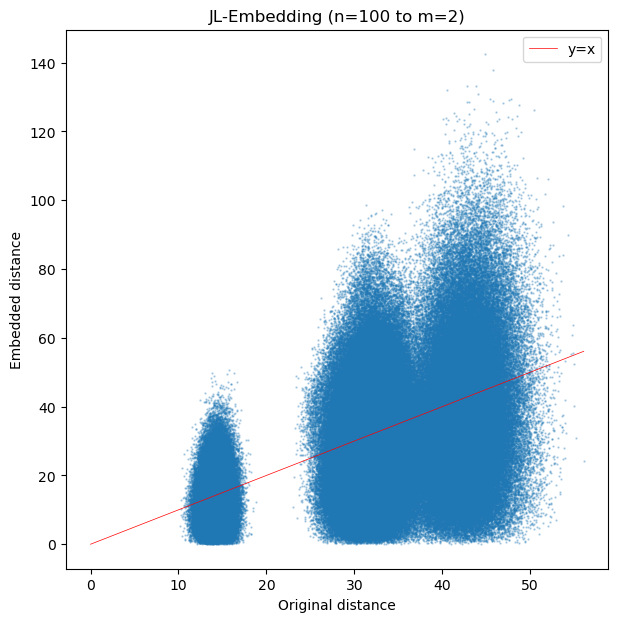

Result: m=2 is a bad JL-Embedding dimension, since the points do not lie on the diagonal


In [17]:
n = 100
p = 1000
m = 2

# Is m=2 a good choice?
eps = np.sqrt(np.log(p)/m)
# eps=1.86
# eps is too large, or other constants should be set properly
# m=2 is too small

X = generate_dataset(n,p)
A = generate_JL_embedding(m,n,'Gauss')
XC = A @ X # shape: (m,p)

# sklearn row-wise => transpose
origin_dists = pairwise_distances(X.T) # shape: (p,p)
embed_dists = pairwise_distances(XC.T) # shape: (p,p)

# remove diagonal and duplicates
up_tri_idx = np.triu_indices_from(origin_dists, k=1)
origin_dist = origin_dists[up_tri_idx]
embed_dist = embed_dists[up_tri_idx]

plt.figure(figsize=(7,7))
plt.scatter(origin_dist, embed_dist, alpha=0.3, s=0.5)
plt.plot([0, max(origin_dist)], [0, max(origin_dist)], color='red', linewidth=0.5, label='y=x')
plt.title(f'JL-Embedding (n={n} to m={m})')
plt.xlabel('Original distance')
plt.ylabel('Embedded distance')
plt.legend()
plt.show()

print('Result: m=2 is a bad JL-Embedding dimension, since the points do not lie on the diagonal')

Take $p = 100$, $n = 100000$ and $m \in \{ 100, 1000, 10000\}$. Compute the resulting constant $\varepsilon$ in
$$
(1 - \varepsilon) \|x-y\|_2^2 \le \| \tfrac{1}{\sqrt{m}} A (x-y) \|_2^2 \le (1 + \varepsilon) \|x-y\|_2^2 
\quad \text{for all} \quad x,y \in X.
$$
Also, compute the direct computation time of the pairwise distances and between the embeddings. What do you observe?  

In [24]:
p = 100
m_list = [100, 1000, 10000]
n = 100000
dist = 'Rademacher'

eps_est = np.zeros(len(m_list))


X = generate_dataset(n,p)

start = timer()
true_d = pairwise_distances(X.T, metric='sqeuclidean')
end = timer()
direct_time = end - start

for mi in range(len(m_list)):
    m = m_list[mi]

    start = timer()
    A = generate_JL_embedding(m,n,dist)
    XC = A @ X
    compr_d = pairwise_distances(XC.T, metric='sqeuclidean')
    end = timer()
    comp_time = end - start

    # remove diagonal and duplicates
    idx = np.triu_indices_from(true_d, k=1)
    ratio = (compr_d[idx] / true_d[idx])**2
    eps_est[mi] = np.max(np.abs((ratio - 1)))

    print(f'For p={p}, m={m}, n={n}, the estimated JL constant is {eps_est[mi]:.3f}, Time direct:{direct_time:.3f}, Time compressed:{comp_time:.3f}')

# trade-off between embedding dimension and runtime
# increasing m => eps decreases
# runtime explodes by JL embedding for m=10000, n=100000 due to matrix multiplication


For p=100, m=100, n=100000, the estimated JL constant is 1.387, Time direct:3.003, Time compressed:1.393
For p=100, m=1000, n=100000, the estimated JL constant is 0.310, Time direct:3.003, Time compressed:2.985
For p=100, m=10000, n=100000, the estimated JL constant is 0.121, Time direct:3.003, Time compressed:106.396


# Sparse Recovery

Now, we explore compression and recovery from the measurement. Let $n = 500$ and $s = 50$. Generate $s$-sparse $x \in \mathbb R^n$, e.g., by sampling $x_i \sim \mathcal N(0,1)$ for $i \in [s]$ and $x_i = 0$ otherwise. Compute its compression $y = \tfrac{1}{\sqrt m} A x$ with $A$ as in Exercise 5.1. Then, implement Basis Pursuit via the linear program from Exercise 5.4 (see [scipy.optimize.linprog](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html)). To evaluate the performance of recovery, for 
$$
  m \in \{s, \frac{5s}{4}, \ldots, \frac{n}{2} - \frac{s}{4}\} 
$$
we compute the solution $x^{(m)}$ of Basis Pursuit and compute two metrics, relative reconstruction error and support recovery rate
$$
  \textrm{Rel.Err} = \frac{\| x - x^{(m)}\|_2}{\| x\|_2}
  \quad \text{and} \quad
  \textrm{Supp.Rate} = \frac{| \operatorname{supp}(x) \cap \operatorname{supp}(x^{(m)})| }{| \operatorname{supp}(x) \cup \operatorname{supp}(x^{(m)})|}
$$ 
Plot both metrics as a function of oversampling ratio, $m/s$. What do you observe? What happens if you add Gaussian noise $e$, with i.i.d. $e_i \sim 0.01 \mathcal N(0,1)$ to the measurements $\tilde y= y + e$?

In [6]:
from scipy.optimize import linprog

In [25]:
s = 50
n = 500

x = np.zeros(n)
x[:s] = np.random.randn(s)

m_list = np.arange(s, n//2, s//4)
errors = np.zeros((len(m_list)))
support = np.zeros((len(m_list)))
tol = 1e-6

for mi in range(len(m_list)):
    m = m_list[mi]
    A = generate_JL_embedding(m,n,dist)
    y = A @ x
    
    c = np.ones((2*n))
    M = np.hstack((A, -A))
    v_est = linprog(c, M, y).x
    x_est = v_est[:n] - v_est[n:]
    idx = np.abs(x_est) > tol
   
    support[mi] = np.sum(idx[:s])*1.0 / (s + np.sum(idx[s:])) 
    errors[mi] = np.linalg.norm(x - x_est) / np.linalg.norm(x)
    print(m, ' samples: rel. residual:', errors[mi], 'support recovery rate:', support[mi])

50  samples: rel. residual: 1.1024625240396708 support recovery rate: 0.08
62  samples: rel. residual: 1.10190334366601 support recovery rate: 0.041666666666666664
74  samples: rel. residual: 1.016663377161422 support recovery rate: 0.1038961038961039
86  samples: rel. residual: 1.0488962685620435 support recovery rate: 0.16049382716049382
98  samples: rel. residual: 0.9810834330420394 support recovery rate: 0.12087912087912088
110  samples: rel. residual: 0.9072442965934057 support recovery rate: 0.17894736842105263
122  samples: rel. residual: 0.8520594812483673 support recovery rate: 0.1827956989247312
134  samples: rel. residual: 0.9550802478451018 support recovery rate: 0.17142857142857143
146  samples: rel. residual: 0.8937976595143967 support recovery rate: 0.17
158  samples: rel. residual: 0.722353232414938 support recovery rate: 0.24770642201834864
170  samples: rel. residual: 0.6280630372331929 support recovery rate: 0.20512820512820512
182  samples: rel. residual: 0.63118178

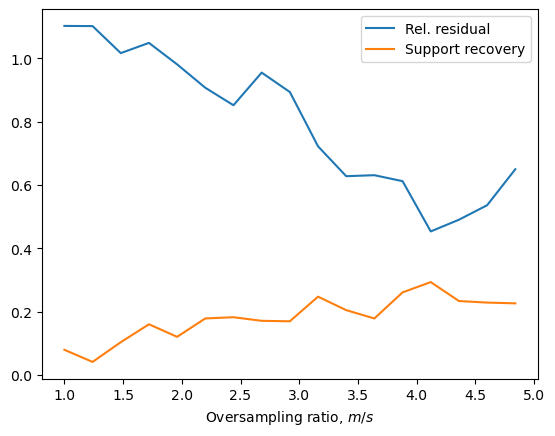

In [26]:
plt.plot(1.0*m_list/s, errors)
plt.plot(1.0*m_list/s, support)
plt.xlabel('Oversampling ratio, $m/s$')
plt.legend(['Rel. residual', 'Support recovery'])
plt.show()